<a href="https://colab.research.google.com/github/ophidian1924-orion/ufc_fight_predictor/blob/main/notebooks/without_odds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import files

uploaded = files.upload()

Saving processed_ufc_fights.csv to processed_ufc_fights.csv


In [3]:
df = pd.read_csv("processed_ufc_fights.csv")
df.head()

,red_odds,blue_odds,red_winner,odds_diff,age_diff,reach_diff,height_diff,wins_diff,losses_diff,rounds_diff,...,red_reach_per_height,blue_reach_per_height,red_days_since_last,blue_days_since_last,red_debut,blue_debut,activity_diff,red_elo,blue_elo,elo_diff
0,140,-160,0,300,-2,10.16,10.16,1,2,1,...,1.000000,1.000000,NaN,NaN,1,1,NaN,1500.0,1500.0,0.0
1,-420,335,1,-755,-5,-7.62,-10.16,1,1,6,...,1.029412,1.013889,NaN,NaN,1,1,NaN,1500.0,1500.0,0.0
2,-260,220,1,-480,0,2.12,2.54,0,0,0,...,1.026316,1.028871,NaN,NaN,1,1,NaN,1500.0,1500.0,0.0
3,-210,175,1,-385,-2,-7.62,-7.62,3,0,9,...,1.059701,1.057143,NaN,NaN,1,1,NaN,1500.0,1500.0,0.0
4,-155,135,0,-290,6,-2.54,0.00,2,1,5,...,1.000000,1.014286,NaN,NaN,1,1,NaN,1500.0,1500.0,0.0


In [4]:
df = df.replace([np.inf, -np.inf], 0)

In [5]:
df = df.drop(['red_odds', 'blue_odds', 'odds_diff', 'red_implied_prob', 'blue_implied_prob', 'prob_diff'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7265 entries, 0 to 7264
Data columns (total 76 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   red_winner                          7265 non-null   int64  
 1   age_diff                            7265 non-null   int64  
 2   reach_diff                          7265 non-null   float64
 3   height_diff                         7265 non-null   float64
 4   wins_diff                           7265 non-null   int64  
 5   losses_diff                         7265 non-null   int64  
 6   rounds_diff                         7265 non-null   int64  
 7   title_bout_diff                     7265 non-null   int64  
 8   ko_diff                             7265 non-null   int64  
 9   submission_diff                     7265 non-null   int64  
 10  win_streak_diff                     7265 non-null   int64  
 11  lose_streak_diff                    7265 no

In [6]:
#Split the data into training and testing data
X = df.drop('red_winner', axis=1)
y = df['red_winner']

train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [7]:
#Classify the model
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",

    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
)

In [8]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(accuracy)

0.5980729525120441


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.57      0.39      0.46       643
           1       0.61      0.76      0.68       810

    accuracy                           0.60      1453
   macro avg       0.59      0.58      0.57      1453
weighted avg       0.59      0.60      0.58      1453



In [12]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

array([[250, 393],
       [191, 619]])

In [13]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    y_test,
    probabilities[:,1]
)

np.float64(0.6130330434114779)

<Figure size 1000x600 with 0 Axes>

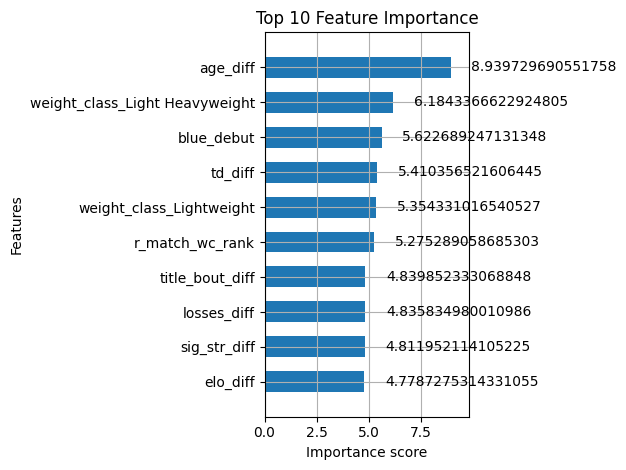

In [14]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_importance(
    model,
    max_num_features=10,
    importance_type='gain',   # Better than 'weight'
    height=0.6
)
plt.title("Top 10 Feature Importance")
plt.tight_layout()
plt.show()